# Workflow for Evaluation and Optimize of Post

In [ ]:
"""
                                            --> Approved  --> ENd
START --> Generate(LLM) --> Evaluation(LLM) --> need_improvements  --> Optimize
                                ^_____________________________________|
"""

In [41]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage,HumanMessage
import operator
from pydantic import BaseModel, Field

In [42]:
load_dotenv()

generation_model = ChatOpenAI()
evaluation_model = ChatOpenAI()
optimizer_model = ChatOpenAI()

In [43]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved","need_improvements"]
    feedback: str
    iteration: int
    max_iteration: int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [44]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [45]:
structured_evaluator_llm = evaluation_model.with_structured_output(TweetEvaluation)

c:\Users\DELL\Desktop\Agentic-AI-Using-LangGraph\myagentvenv\Lib\site-packages\langchain_openai\chat_models\base.py:2493: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [46]:
def generate(state:TweetState):
    messages = [
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
]
    response = generation_model.invoke(messages).content
    return {'tweet': response, 'tweet_history': [response]}

def evaluate(state:TweetState):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]} 

def optimize(state:TweetState):
    messages = [
    SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
    HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
]

    response = optimizer_model.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [47]:
def check_evaluation(state:TweetState):
    if state['evaluation'] == "approved" or state['iteration'] >= state['max_iteration']:
        return "approved"
    else:
        return "need_improvements"

In [48]:
graph = StateGraph(TweetState)

graph.add_node("generate",generate)
graph.add_node("evaluate",evaluate)
graph.add_node("optimize",optimize)


graph.add_edge(START,"generate")
graph.add_edge("generate","evaluate")

graph.add_conditional_edges("evaluate",check_evaluation, {"approved":END,"need_improvements":'optimize'})

graph.add_edge('optimize',"evaluate")

workflow = graph.compile()

In [49]:
initial_state = {
    "topic": "dfhjkjhgvb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [50]:
result

{'topic': 'dfhjkjhgvb',
 'tweet': '*Me trying to type out "dfhjkjhgvb"*\n\nAuto-correct: "Did you mean \'Squirrel on a unicycle in a turtleneck\'? 🤔\n\nHonestly, that\'s exactly what I was going for. Nailed it, auto-correct. ',
 'evaluation': 'approved',
 'feedback': 'This tweet is approved as it meets the criteria for evaluation. It demonstrates originality with a unique take on auto-correct suggestions, making it fresh and engaging. The humor is evident with the unexpected and amusing suggestion by auto-correct, which can genuinely make readers chuckle. The tweet is punchy and concise, capturing the humor in a succinct manner. Its potential for virality is high due to its relatability and the humor that resonates with many. Additionally, the tweet is well-formed, avoiding common pitfalls like question-answer format or weak concluding lines.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['*Me trying to type out "dfhjkjhgvb"*\n\nAuto-correct: "Did you mean \'Squirrel on a u

In [51]:
for tweet in result['tweet_history']:
    print(tweet)

*Me trying to type out "dfhjkjhgvb"*

Auto-correct: "Did you mean 'Squirrel on a unicycle in a turtleneck'? 🤔

Honestly, that's exactly what I was going for. Nailed it, auto-correct. 


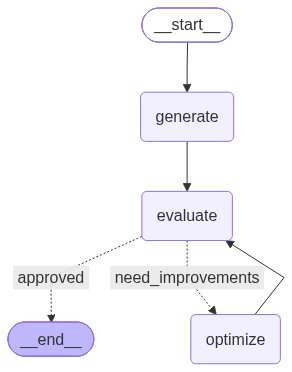

In [52]:
workflow